# **Synthetic Data Generation**

*Generate synthetic data to capture hourly pay rates for nurses in US across the major metros.*

In [ ]:
# Import the necessary libraries
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

**Locations:**

*Dallas (TX), Atlanta (GA), New York (NY), Philadelphia (PA), Washington (DC), San Fransisco (CA), Los Angeles (CA), Seattle (WA), Chicago (IL), San Diego (CA), Miami (FL), Boston (MA), Detroit (MI), Phoenix (AZ), Houston (TX).*

In [ ]:
 # Create a constant for locations (State & City)
locations = ["Dallas, TX", "Atlanta, GA", "New York, NY", "Philadelphia, PA", "Washington, DC",
             "San Fransisco, CA", "Los Angeles, CA", "Seattle, WA", "Chicago, IL", "San Diego, CA",
             "Miami, FL", "Boston, MA", "Detroit, MI", "Phoenix, AZ", "Houston, TX"]

**Job Titles for Nurses:**

*1) RegisteredNurse_ICU\
2) RegisteredNurse_MedSurg\
3) RegisteredNurse_Telemetry\
4) RegisteredNurse_Oncology\
5) RegisteredNurse_Pediatric\
6) PhysioTherapist\
7) LabTechnician\
8) RegisteredNurse_CriticalCare\
9) RegisteredNurse_Cardiology\
10) RegisteredNurse_Surgery*

In [ ]:
# Create a list of job titles for nurses
job_titles = ["RegisteredNurse_ICU", "RegisteredNurse_MedSurg", "RegisteredNurse_Telemetry",
              "RegisteredNurse_Oncology", "RegisteredNurse_Pediatric", "PhysioTherapist", "LabTechnician",
              "RegisteredNurse_CriticalCare", "RegisteredNurse_Cardiology", "RegisteredNurse_Surgery"]

**Hospital Suffixes:**

*Corporate, NonProfit, Community, Veterans, Govt*

In [ ]:
# Create a list of hospital suffixes
hospital_suffixes = ["Corporate", "NonProfit", "Community", "Veterans", "Govt"]

**Hospital Name:**

*Generate Hospital name using City name from `locations` as prefix followed by a suffix that could be any one from `hospital_suffixes`*

In [ ]:
# Function to generate hospital names
def generate_hospital_name(location):
  city = location.split(",")[0]   # Selects only the city name
  suffix = random.choice(hospital_suffixes)   # Chooses random suffix from the given options

  return f"{city} {suffix} Hospital"    # Returns the hospital name with city as prefix followed by a suffix

**Hourly Pay Rate:**

*Shows seasonal uptick during Flu & Christmas holiday season.*

In [ ]:
# Function to generate hourly pay rates
def generate_hourly_pay_rate(base_rate, season):
  if season == "normal":
    return round(np.random.normal(base_rate, 2), 2)   # base pay during normal season
  elif season == "flu":
    return round(np.random.normal(base_rate * 1.2, 2), 2)   # 1.2 times base pay during flu season
  elif season == "holiday":
    return round(np.random.normal(base_rate * 1.3, 2), 2)   # 1.3 times base pay during holiday season

**Base Hourly Rates**

In [ ]:
# Base hourly rates for differrent job titles
base_rates = {"RegisteredNurse_ICU": 40,
              "RegisteredNurse_MedSurg": 35,
              "RegisteredNurse_Telemetry": 38,
              "RegisteredNurse_Oncology": 42,
              "RegisteredNurse_Pediatric": 37,
              "PhysioTherapist": 45,
              "LabTechnician": 30,
              "RegisteredNurse_CriticalCare": 45,
              "RegisteredNurse_Cardiology": 43,
              "RegisteredNurse_Surgery": 50}

**Generate Synthetic Data**

*Using all the previously generated columns, now generate the entire data of 2,50,000 rows.\
Each row should contain Job Title, Location (State & City), Hospital Name,
Contract start date, Contract end date, Hourly Pay rate.*

In [ ]:
# Generate synthetic data
data = []
num_rows = 250000

for _ in range(num_rows):
  location = random.choice(locations)
  job_title = random.choice(job_titles)
  hospital_name = generate_hospital_name(location)

  # Generate contract dates
  start_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 730))    # Random date in 2023-2024
  end_date = start_date + timedelta(weeks=random.randint(1, 13))    # Contract duration up to 13 weeks

  # Determine season
  month = start_date.month

  if month in [10, 11, 1, 2, 3, 4, 5]:   # Flu season (October - May) (except December as we consider it as holiday season and consider only the highest pay rate)
    season = "flu"
  elif month == 12:   # Christmas holiday season
    season = "holiday"
  else:
    season = "normal"

  # Generate hourly pay rate
  base_rate = base_rates[job_title]
  hourly_pay_rate = generate_hourly_pay_rate(base_rate, season)

  # Append to data list
  data.append([job_title, location, hospital_name, start_date.date(), end_date.date(), season, hourly_pay_rate])

**Create a DataFrame**

In [ ]:
# Create a DataFrame
columns = ["Job_Title", "Location", "Hospital_Name", "Contract_Start", "Contract_End", "Season", "Hourly_Pay"]
data = pd.DataFrame(data, columns=columns)

**Save the DataFrame as CSV**

In [ ]:
data.to_csv("Synthetic_Nurse_Pay_Data.csv", index=False)

# **EDA**

In [ ]:
# Import libraries required for EDA
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
# EDA
df = pd.read_csv("Synthetic_Nurse_Pay_Data.csv")
df.shape

(250000, 7)

In [ ]:
df.head()

,Job_Title,Location,Hospital_Name,Contract_Start,Contract_End,Season,Hourly_Pay
0,RegisteredNurse_Oncology,"San Diego, CA",San Diego NonProfit Hospital,2023-01-08,2023-03-05,flu,53.95
1,RegisteredNurse_Surgery,"Phoenix, AZ",Phoenix Community Hospital,2023-05-12,2023-07-28,flu,56.02
2,RegisteredNurse_CriticalCare,"Detroit, MI",Detroit Veterans Hospital,2023-08-27,2023-11-19,normal,43.77
3,RegisteredNurse_ICU,"New York, NY",New York NonProfit Hospital,2023-08-25,2023-10-06,normal,38.93
4,RegisteredNurse_Cardiology,"Chicago, IL",Chicago Corporate Hospital,2024-10-27,2024-11-24,flu,53.89


In [ ]:
df.isnull().sum()

,0
Job_Title,0
Location,0
Hospital_Name,0
Contract_Start,0
Contract_End,0
Season,0
Hourly_Pay,0


In [ ]:
df.dtypes

,0
Job_Title,object
Location,object
Hospital_Name,object
Contract_Start,object
Contract_End,object
Season,object
Hourly_Pay,float64


In [ ]:
df.describe()

,Hourly_Pay
count,250000.000000
mean,46.252517
std,7.806319
min,22.700000
25%,40.820000
50%,46.100000
75%,51.920000
max,72.170000


In [ ]:
list(df.columns)

['Job_Title',
 'Location',
 'Hospital_Name',
 'Contract_Start',
 'Contract_End',
 'Season',
 'Hourly_Pay']

### **1. a. Variations of the hourly pay rates across the major metros**

*We can use a box plot for visualizing this.*

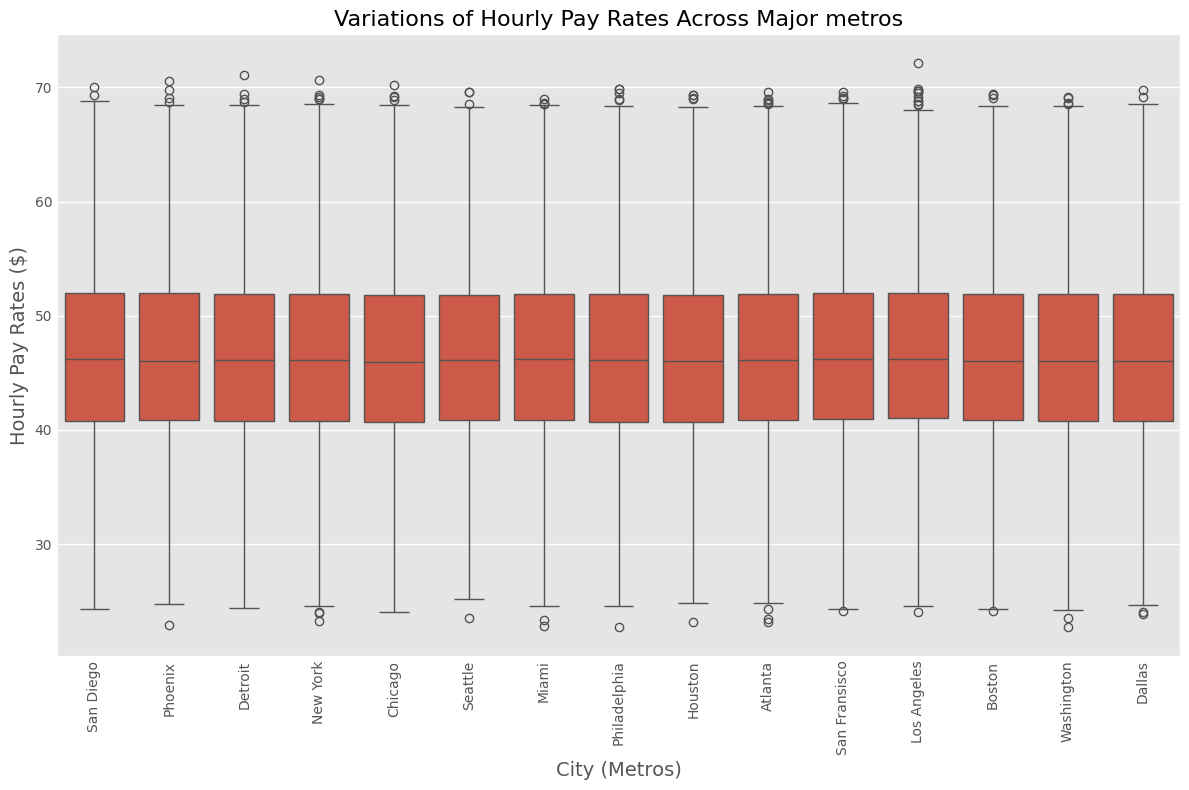

In [ ]:
# Extract city from the Location column
df['City'] = df['Location'].apply(lambda x: x.split(",")[0])    # Apply lambda function to split state from all the locations in the location column

# Create a box plot for hourly pay rates by metro cities
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='City', y='Hourly_Pay')
plt.title('Variations of Hourly Pay Rates Across Major metros', fontsize=16)
plt.xlabel('City (Metros)', fontsize=14)
plt.ylabel('Hourly Pay Rates ($)', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **1. b. Show the uptick in pay rates during flu & holiday season**

*We can use a bar plot to visualize this.*

In [ ]:
df['Season'].value_counts()

,count
Season,
flu,145571
normal,83092
holiday,21337


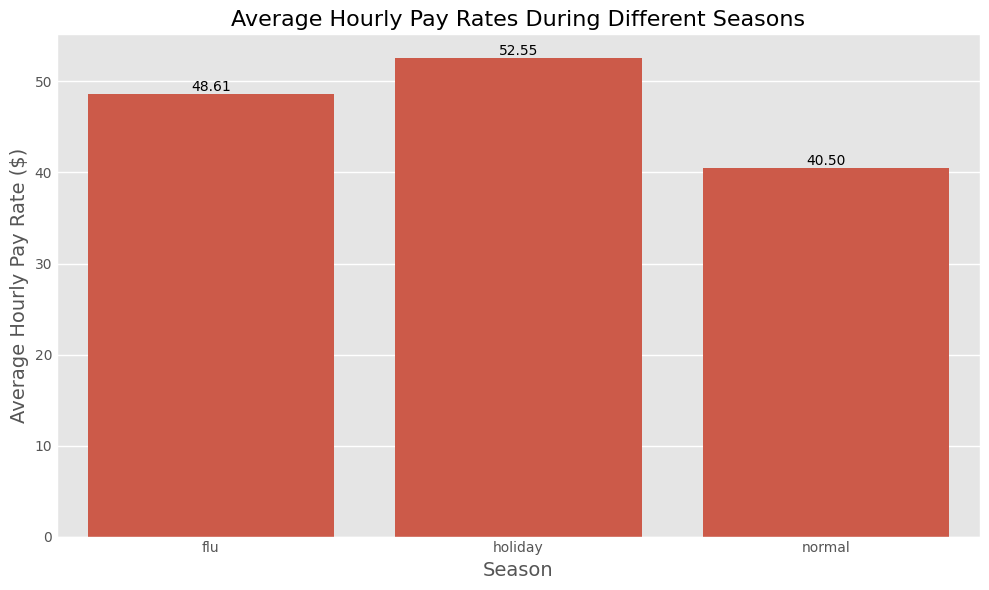

In [ ]:
# Group by season and calculate the average pay rate
seasonal_pay = df.groupby('Season')['Hourly_Pay'].mean().reset_index()

# Create a bar plot for seasonal pay rates
plt.figure(figsize=(10, 6))
ax = sns.barplot(seasonal_pay, x='Season', y='Hourly_Pay')
plt.title('Average Hourly Pay Rates During Different Seasons', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Average Hourly Pay Rate ($)', fontsize=14)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

### **1. c. Show hourly pay rates against the desirability of a city (cost of living, schools, crime rates, public transport, etc.)**

*Create a hypothetical desirability score for each city based on factors.\
Then visualize it through a line plot.*

In [ ]:
# Hypothetical desirability scores for each city
desirability_scores = {"Dallas": 70,
                       "Atlanta": 65,
                       "New York": 50,
                       "Philadelphia": 60,
                       "Washington": 75,
                       "San Fransisco": 40,
                       "Los Angeles": 55,
                       "Seattle": 60,
                       "Chicago": 55,
                       "San Diego": 70,
                       "Miami": 65,
                       "Boston": 75,
                       "Detroit": 50,
                       "Phoenix": 60,
                       "Houston": 65}

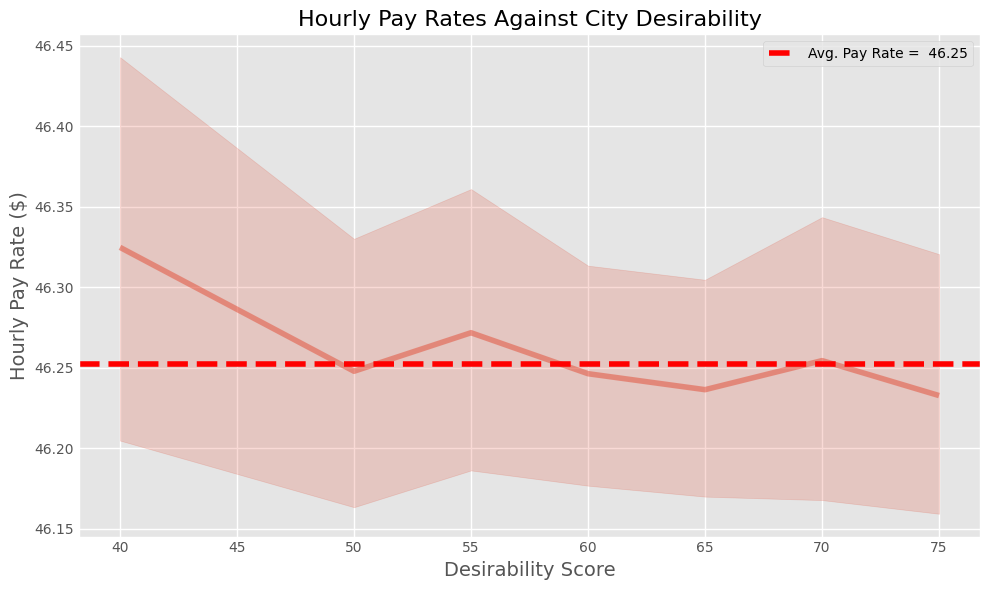

In [ ]:
# Map desirability scores to the DataFrame
df['Desirability_Score'] = df['City'].map(desirability_scores)

# Create a line plot for hourly pay rates against desirability scores
avg_pay = df['Hourly_Pay'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(df, x='Desirability_Score', y='Hourly_Pay', alpha=0.5)
plt.title('Hourly Pay Rates Against City Desirability', fontsize=16)
plt.xlabel('Desirability Score', fontsize=14)
plt.ylabel('Hourly Pay Rate ($)', fontsize=14)
plt.axhline(y=avg_pay, color='r', linestyle='--', label=f'Avg. Pay Rate = {avg_pay: .2f}')
plt.legend()
plt.tight_layout()
plt.show()

### **1. d. Show specialization (oncology, cardiology, surgery) getting higher pay vs other job titles**

*Bar plot can be used to compare the pay rates.*

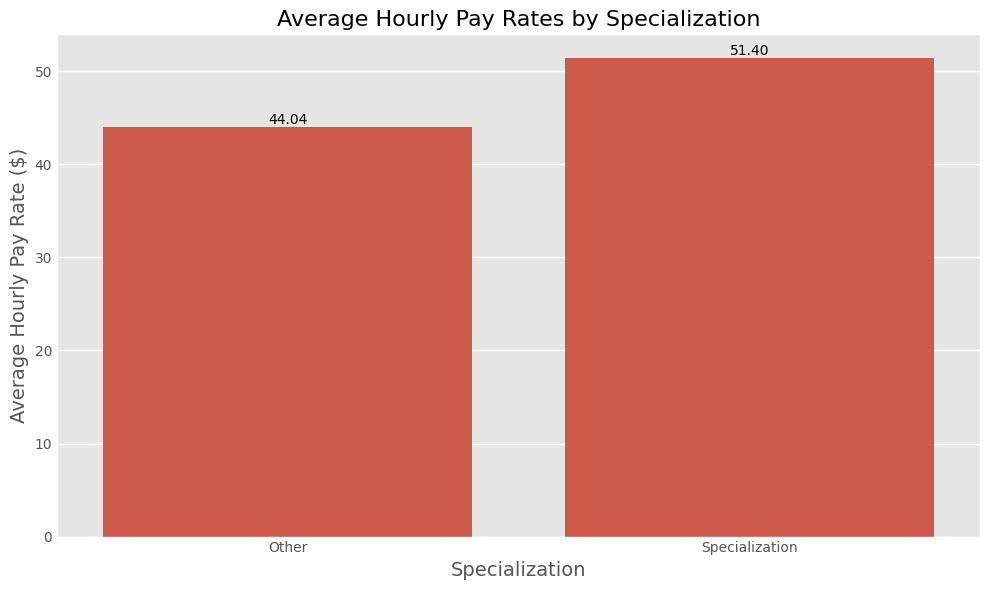

In [ ]:
# Create a new column to categorize job titles
df['Specialization'] = df['Job_Title'].apply(lambda x: 'Specialization' if 'Oncology' in x or 'Cardiology' in x or 'Surgery' in x else 'Other')

# Group by Specialization and calculate the average pay rates
specialization_pay = df.groupby('Specialization')['Hourly_Pay'].mean().reset_index()

# Create a bar plot for specialization pay rates
plt.figure(figsize=(10, 6))
ax = sns.barplot(specialization_pay, x='Specialization', y='Hourly_Pay')
plt.title('Average Hourly Pay Rates by Specialization', fontsize=16)
plt.xlabel('Specialization', fontsize=14)
plt.ylabel('Average Hourly Pay Rate ($)', fontsize=14)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

# **ML/DL Models**

## **2. To predict hourly pay rates for nurses, we can implement two machines learning models:**

- **Random Forest Regressor**
- **XGBoost Regressor**

### **Random Forest Regressor**

*Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the average prediction of the individual trees.\
It is robust against overfitting and can handle non-linear relationships well.*

**Ensure Version Compatibility**

!pip install xgboost==1.7.6 scikit-learn==1.2.2

In [ ]:
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
# Prepare features and target variable
X = df.drop(columns=['Hourly_Pay'])
y = df['Hourly_Pay']

# Create a LabelEncoder for categorical features
categorical_features = ['Job_Title', 'Location', 'Hospital_Name', 'Season', 'City', 'Specialization']

for feature in categorical_features:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature])

# Convert Contract_Start and Contract_End to numerical features
X['Contract_Start'] = pd.to_datetime(X['Contract_Start']).astype(int) / 10**9  # Convert to Unix timestamp
X['Contract_End'] = pd.to_datetime(X['Contract_End']).astype(int) / 10**9  # Convert to Unix timestamp

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

### **XGBoost Regressor**

*XGBoost (Extreme Gradient Boosting) is a powerful gradient boosting framework that is efficient and scalable.\
It is particularly effective for structured data and often yields better performance than traditional models.*

In [ ]:
import xgboost as xgb

# Initialize and fit the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [ ]:
# Make predictions
xgb_predictions = xgb_model.predict(X_test)

### **Justification for Model Selection**

**a. Random Forest Regressor**

- **Robustness:** Random Forest is less prone to overfitting compared to individual decision trees, making it suitable for datasets with noise.
- **Feature Importance:** It provides insights into feature importance, ehich can help in understanding the factors influencing pay rates.
- **Handling Non-Linearity:** It can capture complex relationships between features and the target variable without requiring extensive feature engineering.

**b. XGBoost Regressor**

- **Performance:** XGBoost is known for its high performance in regression tasks, often outperforming other models in competitions and real-world applications.
- **Speed and Efficiency:** It is optimized for speed and can handle large datasets efficiently, making it suitable for real-time predictions.
- **Regularization:** XGBoost includes regularization parameters that help prevent overfitting, which is crucial when dealing with complex datasets.

\
**Conclusion**

By implementing both Random Forest and XGBoost, we can leverage the strengths of ensemble learning and gradient boosting to achieve accurate predictions of hourly pay rates for nurses. The combination of these models allows for a comprehensive analysis of the data, ensuring that we capture both linear and non-linear relationships effectively.

## **3. Handling High Cardinality of Hospitals and Model Evaluation Metrics**

### **a. Handling High Cardinality of Hospitals**

High cardinality refers to categorical variables that have a large number of unique values. In this case, the `Hospital_Name` feature can have thousands of unique entries, which can lead to issues such as overfitting and increased computational complexity. Here are some methods to handle high cardinality, along with their pros and cons:

**1. Target Encoding**

Replace each hospital name with the mean hourly pay rate for that hospital. This method captures the relationship between the hospital and the target variable.

**Implementation:**
```
import category_encoders as ce

# Target encoding for the hospital name feature
target_encoder = ce.TargetEncoder(cols=['Hospital_Name'])
df['Hospital_Name'] = target_encoder.fit_transform(df['Hospital_Name'], df['Hourly_Pay'])

```

**Pros:**

- Reduces dimensionality significantly.
- Captures the relationship between the categorical variable and the target variable.

**Cons:**

- Can lead to overfitting if not handled properely (e.g. using cross-validation).
- May not generalize well to unseen data.

**2. Frequency Encoding**

Replace each hospital name with its frequency in the dataset. This method provides a simple representation of the categorical variable.

**Implementation:**

```
# Frequency encoding for the hospital name feature
hospital_counts = df['Hospital_Name'].value_counts()
df['Hospital_Name_Frequency'] = df['Hospital_Name'].map(hospital_counts)

```

**Pros:**

- Simple to implement and understand.
- Reduces dimensionality while retaining some information about the categorical variable.

**Cons:**

- Loses the relationship between the hospital and the target variable.
- May not capture the nuances of the data.

**3. Dimenionality Reduction Techniques (e.g. PCA)**

Use techniques like Principal Component Analysis (PCA) to reduce the dimensionality of the encoded feature.

**Pros:**

- Can capture the variance in the data while reducing dimensionality.
- Helps in visualizing high-dimensional data.

**Cons:**

- Can be complex to implement and interpret.
- May lose interpretability of the original features.

### **b. Metrics Used for Measuring the Accuracy of the Model**

When evaluating regression models, several metrics can be used to measure their performance. Here are the metrics we will use for both the Random Forest and XGBoost models:



**1. Mean Absolute Error (MAE)**

The average of the absolute differences between predicted and actual values.

**Formula:** $ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $

**Pros:**

- Easy to interpret; represents the average error in the same units as the target variable.
- Less sensitive to outliers compared to other metrics.

**Cons:**

- Does not penalize larger errors more than smaller ones.

**2. Mean Squared Error (MSE)**

The average of the squared differences between predicted and actual values.

**Formula:** $ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

**Pros:**

- Penalizes larger errors more than smaller ones, making it sensitive to outliers.
- Useful for optimization as it is differentiable.

**Cons:**

- The units are squared, which can make interpretation less intuitive.

**3. R-squared ($R^2$)**

Represents the proportion of variance in the target variable that can be explained by the model.

**Formula:** $ {R^2} = 1 - \frac{\text{SS}_\text{res}}{\text{SS}_\text{tot}} $

**Pros:**

- Provides a measure of how well the model explains the variability of the target variable.
- Ranges from 0 to 1, where higher values indicate better model performance.

**Cons:**

- Can be misleading if used alone, especially in the presence of overfitting.
- Does not indicate whether the model is appropriate.

**Implementation of Metrics**

In [ ]:
# Import metrics from sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest Metrics:')
print(f'MAE: {rf_mae:.4f}')
print(f'MSE: {rf_mse:.4f}')
print(f'R-squared: {rf_r2:.4f}')

# XGBoost Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print('\nXGBoost Metrics:')
print(f'MAE: {xgb_mae:.4f}')
print(f'MSE: {xgb_mse:.4f}')
print(f'R-squared: {xgb_r2:.4f}')


Random Forest Metrics:
MAE: 1.7229
MSE: 4.6546
R-squared: 0.9237

XGBoost Metrics:
MAE: 1.6084
MSE: 4.0664
R-squared: 0.9334


## **4. Streamlit Application for Predicting Hourly Pay Rates for Nurses**

In [ ]:
!pip install streamlit category_encoders pyngrok

In [ ]:
%%writefile app.py
#Import the libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import streamlit as st
import category_encoders as ce

# Load the dataset
data1 = pd.read_csv("Synthetic_Nurse_Pay_Data.csv")

# Preprocess the data
data1['Contract_Start'] = pd.to_datetime(data1['Contract_Start'])
data1['Contract_End'] = pd.to_datetime(data1['Contract_End'])

# Feature engineering: Extract contract duration from dates
data1['Contract_Duration'] = (data1['Contract_End'] - data1['Contract_Start']).dt.days

# Encoding categorical variables
encoder = ce.TargetEncoder(cols=['Job_Title', 'Location', 'Hospital_Name'])
data1_encoded = encoder.fit_transform(data1[['Job_Title', 'Location', 'Hospital_Name']], data1['Hourly_Pay'])
data1_encoded['Contract_Duration'] = data1['Contract_Duration']

# Split the data into training and testing sets
X = data1_encoded
y = data1['Hourly_Pay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

# Streamlit application interface
st.title('Nurse Hourly Pay Rate Prediction')
st.write("Enter the details below to predict the hourly pay rate for a nurse.")

# User inputs
job_title = st.selectbox('Select Job Title', data1['Job_Title'].unique())
location = st.selectbox('Select Location', data1['Location'].unique())
hospital_name = st.selectbox('Select Hospital Name', data1['Hospital_Name'].unique())
contract_start = st.date_input('Contract Start Date')
contract_end = st.date_input('Contract End Date')

# Calculate contract duration
contract_duration = (contract_end - contract_start).days

# Predict button
if st.button('Predict Hourly Pay Rate'):
  input_data = pd.DataFrame({'Job_Title': [job_title],
                             'Location': [location],
                             'Hospital_Name': [hospital_name],
                             'Contract_Duration': [contract_duration]})

  # Encode the input data
  input_encoded = encoder.transform(input_data[['Job_Title', 'Location', 'Hospital_Name']])
  input_encoded['Contract_Duration'] = input_data['Contract_Duration']

  # Make prediction
  prediction = xgb_model.predict(input_encoded)

  # Display the predictions result
  st.success(f'The predicted hourly pay rate is: ${prediction[0]:.2f}')

Overwriting app.py


In [ ]:
from pyngrok import ngrok
import os

# Set up ngrok
!ngrok authtoken 2qeexa2UpnBAGA1hoo2W1b25e8j_2H1h5cHGHeX4HfKPfxc25

public_url = ngrok.connect(8501)
os.system('streamlit run app.py &')

print(f'Link to web app: {public_url}')

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Link to web app: NgrokTunnel: "https://1e78-34-125-197-118.ngrok-free.app" -> "http://localhost:8501"


## **5. Timeseries based Forecasting model using Prophet or NeuralProphet or StackedLSTM**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# Load the dataset
data2 = pd.read_csv('Synthetic_Nurse_Pay_Data.csv')

# Ensure the date column is in datetime format
data2['Contract_Start'] = pd.to_datetime(data2['Contract_Start'])

# Group the date and calculate average hourly pay
data2_grouped = data2.groupby('Contract_Start')['Hourly_Pay'].mean().reset_index()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data2_normalized = scaler.fit_transform(data2_grouped['Hourly_Pay'].values.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, time_step):
  X, y = [], []
  for i in range(len(data) - time_step - 1):
    X.append(data[i:(i + time_step), 0])
    y.append(data[i + time_step, 0])
  return np.array(X), np.array(y)

# Set time step
time_step = 10
X, y = create_sequences(data2_normalized, time_step)

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
# Define the stacked LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model
model.fit(X, y, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1642
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0300
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0176
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0167
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0172
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0147
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0150
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0126
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0144
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0139
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0125
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0158
Epoch 13/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0138
Epoch 14/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0111
Epoch 15/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - lo

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


<ipython-input-64-f7ab375df882>:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2_grouped['Predicted'].iloc[time_step:len(train_predict) + time_step] = train_predict.flatten()
<ipython-input-64-f7ab375df882>:9: SettingWithCopyWarning: 


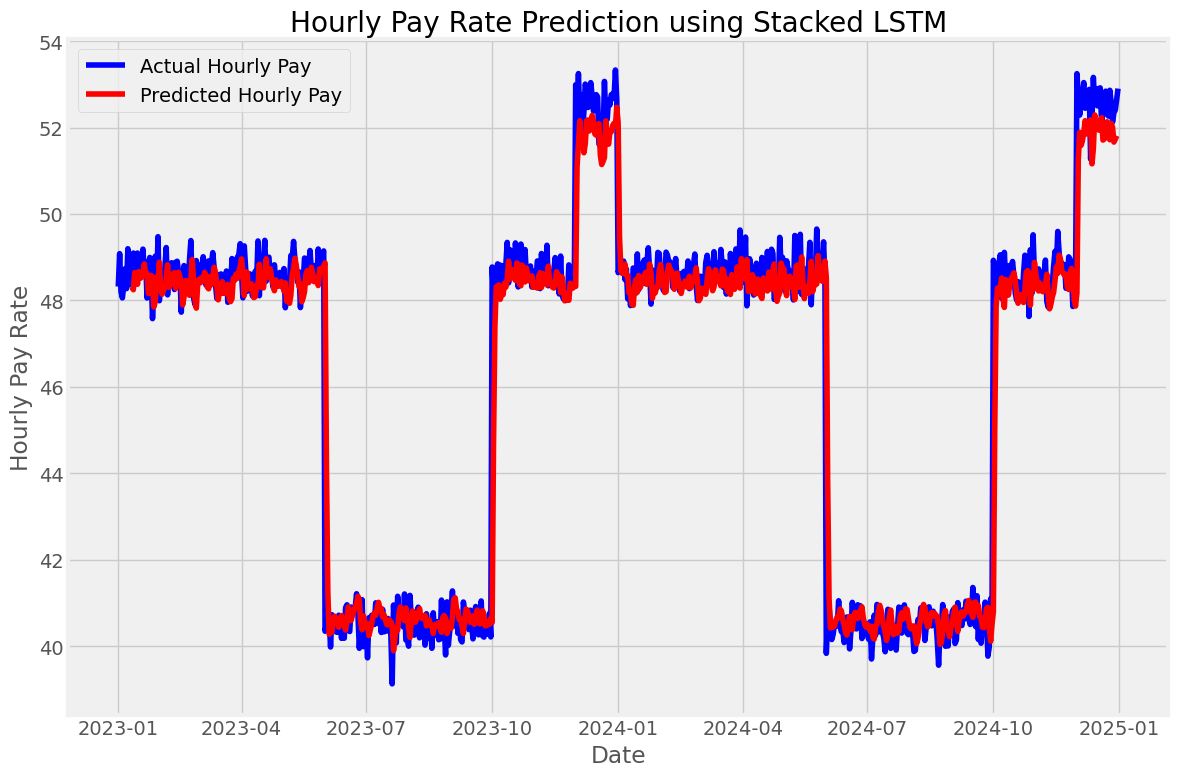

In [ ]:
# Make predictions
train_predict = model.predict(X)

# Inverse transform to get actual values
train_predict = scaler.inverse_transform(train_predict)

# Prepare the data for visualization
data2_grouped['Predicted'] = np.nan
data2_grouped['Predicted'].iloc[time_step:len(train_predict) + time_step] = train_predict.flatten()

# Plot the results
plt.figure(figsize=(12, 8))
plt.style.use('fivethirtyeight')
plt.plot(data2_grouped['Contract_Start'], data2_grouped['Hourly_Pay'], label='Actual Hourly Pay', color='blue')
plt.plot(data2_grouped['Contract_Start'], data2_grouped['Predicted'], label='Predicted Hourly Pay', color='red')
plt.title('Hourly Pay Rate Prediction using Stacked LSTM')
plt.xlabel('Date')
plt.ylabel('Hourly Pay Rate')
plt.legend()
plt.tight_layout()
plt.show()